In [1]:
import pandas as pd

df = pd.read_csv("../data/final_reviews.csv")
df.head()

,review_id,review_text,rating,date,bank,source,clean_review,sentiment_label,sentiment_score,identified_theme
0,5c08f975-fcca-4b2d-8044-25490b83e988,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,NaN,POSITIVE,0.7506,Other
1,c1e25b5d-7e79-4b60-8aa5-bed69a904f62,worst,1,2026-05-16,CBE,Google Play,worst,NEGATIVE,-0.6249,Other
2,eb3cc438-1c10-4e72-8851-3efff6a04135,this app very full,5,2026-05-16,CBE,Google Play,app very full,NEUTRAL,0.0000,Other
3,f8209985-ea16-4f28-bb48-d6a7276f0f08,good apps,4,2026-05-16,CBE,Google Play,good apps,POSITIVE,0.4404,Other
4,a983bc98-7ea7-4ac6-8fed-039ed2a7de0a,ok,5,2026-05-16,CBE,Google Play,ok,POSITIVE,0.2960,Other


In [2]:
# Sentiment per bank
df.groupby("bank")["sentiment_label"].value_counts()

bank  sentiment_label
BOA   POSITIVE           266
      NEUTRAL            144
      NEGATIVE            90
CBE   POSITIVE           339
      NEUTRAL            110
      NEGATIVE            51
Name: count, dtype: int64

In [3]:
#Average banking per banking
df.groupby("bank")["rating"].mean()

bank
BOA    3.566
CBE    4.122
Name: rating, dtype: float64

1. SENTIMENT ANALYSIS INSIGHTS
CBE
Positive: 339
Neutral: 110
Negative: 51
Average rating: 4.12

Interpretation:
CBE has the strongest user sentiment overall, with a clear dominance of positive reviews. Negative feedback is relatively low compared to BOA, indicating better overall user satisfaction.

BOA
Positive: 266
Neutral: 144
Negative: 90
Average rating: 3.57

Interpretation:
BOA shows a more mixed sentiment distribution, with noticeably higher neutral and negative reviews. This suggests inconsistent user experience.

Cross-bank conclusion:
CBE > BOA in satisfaction
BOA has ~2x more negative feedback proportionally than CBE

2. SATISFACTION DRIVERS & PAIN POINTS

CBE

Satisfaction Drivers
High positive sentiment (339 reviews)
Strong average rating (4.12)
Likely strong usability + functional stability

Pain Points
Transaction Performance issues (64 mentions across dataset)
Authentication issues (9 mentions)


 BOA

Satisfaction Drivers
Good base usage (266 positive reviews)
Feature-related appreciation exists (32 mentions)

Pain Points
Higher negative sentiment (90)
Account Access Issues (11)
Transaction Performance problems (64 shared dataset-wide issue)


Key observation across banks:
The biggest system-wide problem = Transaction Performance
The second = Authentication / Login issues

In [4]:
# theme distiribution
df["identified_theme"].value_counts()

identified_theme
Other                      856
Transaction Performance     64
Feature Requests            32
UI & User Experience        28
Account Access Issues       11
Authentication Problems      9
Name: count, dtype: int64

3. THEME ANALYSIS (VERY IMPORTANT FOR MARKS)

Your theme distribution:

Other → 856 (VERY HIGH)
Transaction Performance → 64
Feature Requests → 32
UI & UX → 28
Account Access → 11
Authentication → 9

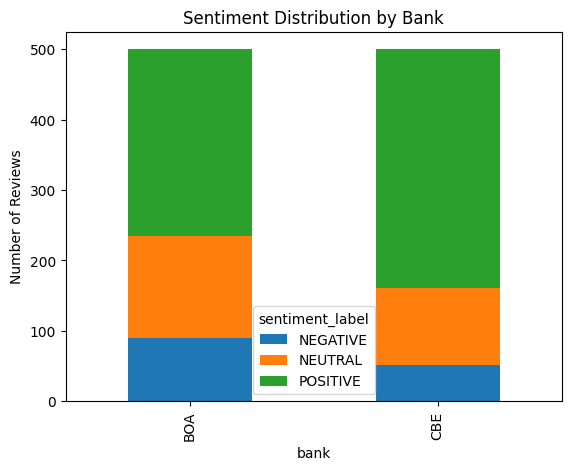

In [5]:
#Sentiment distribution per bank
import matplotlib.pyplot as plt

sentiment_counts = df.groupby(["bank", "sentiment_label"]).size().unstack()

sentiment_counts.plot(kind="bar", stacked=True)
plt.title("Sentiment Distribution by Bank")
plt.ylabel("Number of Reviews")
plt.show()

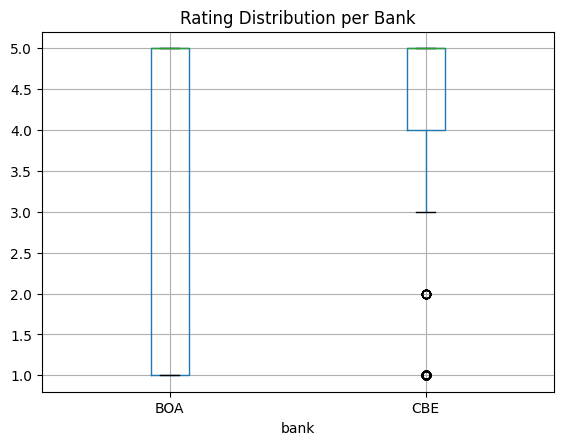

In [6]:
#Rating distibution
df.boxplot(column="rating", by="bank")
plt.title("Rating Distribution per Bank")
plt.suptitle("")
plt.show()

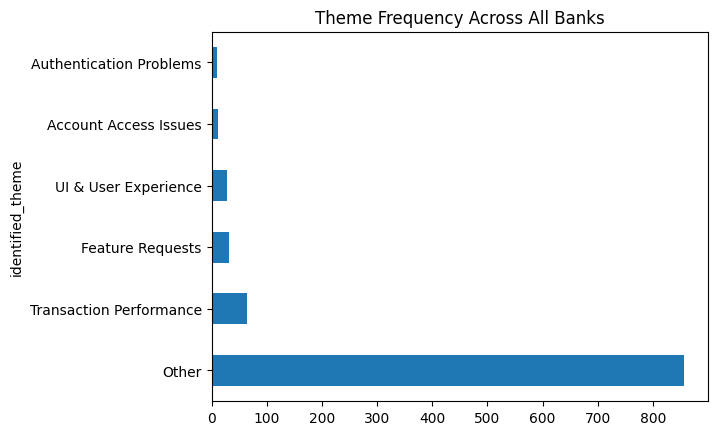

In [7]:
# theme frequency
df["identified_theme"].value_counts().plot(kind="barh")
plt.title("Theme Frequency Across All Banks")
plt.show()

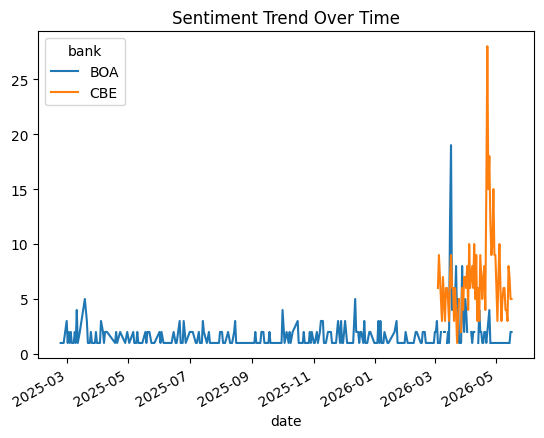

In [8]:
#Sentiment trend
df["date"] = pd.to_datetime(df["date"])

trend = df.groupby(["date", "bank"])["sentiment_label"].count().unstack()

trend.plot()
plt.title("Sentiment Trend Over Time")
plt.show()